# SOLER X-ray Imaging Analysis Workflow

This workflow focuses on the construction of images from STIX pixel data using ``stixpy`` and ``xrayvisim``. 

The initial part of this demonstration is mostly taken from the ``stixpy`` examples which can be found at [STIXpy imaging example.](https://stixpy.readthedocs.io/en/stable/generated/gallery/imaging_demo.html "STIXpy Imaging Example")



How to create visibility from pixel data and make images.

The example uses ``stixpy`` to obtain STIX pixel data and convert these into visibilities and ``xrayvisim``
to make the images.


In [1]:
import logging

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from sunpy.coordinates import HeliographicStonyhurst, Helioprojective
from sunpy.map import Map, make_fitswcs_header
from sunpy.time import TimeRange
from sunpy.net import Fido, attrs as a
from xrayvision.clean import vis_clean
from xrayvision.imaging import vis_to_image, vis_to_map
from xrayvision.mem import mem, resistant_mean
import os

from stixpy.calibration.visibility import calibrate_visibility, create_meta_pixels, create_visibility
from stixpy.coordinates.frames import STIXImaging
from stixpy.coordinates.transforms import get_hpc_info
from stixpy.imaging.em import em
from stixpy.map.stix import STIXMap  # noqa
from stixpy.product import Product

logger = logging.getLogger(__name__)

/home/jmitchell/anaconda3/envs/soler_workshop_imaging_timeseries/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Set-up download 

In [2]:
instrument = a.Instrument.stix
product = a.stix.DataProduct.sci_xray_cpd	

download_dir = './data/'
os.makedirs(download_dir,exist_ok=True)

Download science file 

In [3]:
# Define search parameters
start_time = '2024-03-10T11:00:00'
end_time = '2024-03-10T13:00:00'
time = a.Time(start_time, end_time)

# Search + latest version
resp = Fido.search(instrument, time, product)
sci_table = resp['stix']
sci_table.filter_for_latest_version()
sci_table

Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
Time,Time,str4,str2,str3,str12,str3,int64
2024-03-10T10:58:52.000,2024-03-10T11:25:32.000,STIX,L1,SCI,sci-xray-cpd,V02,2403107510
2024-03-10T11:32:52.000,2024-03-10T11:38:47.000,STIX,L1,SCI,sci-xray-cpd,V02,2403109509
2024-03-10T11:56:26.000,2024-03-10T12:45:18.000,STIX,L1,SCI,sci-xray-cpd,V02,2403102193
2024-03-10T11:59:06.000,2024-03-10T12:15:40.000,STIX,L1,SCI,sci-xray-cpd,V02,2403109216
2024-03-10T12:43:15.000,2024-03-10T14:10:20.000,STIX,L1,SCI,sci-xray-cpd,V02,2403101620


In [ ]:
# Select desired science file from the list and download using Fido.fetch

sci_file_download = Fido.fetch(sci_table[3], path=download_dir)

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded: 100%|██████████| 1/1 [00:31<00:00, 31.50s/file]


Download background file

In [5]:
# Define search parameters
start_time_bkg = '2024-03-08T18:00:00'
end_time_bkg = '2024-03-08T21:00:00'
time_bkg = a.Time(start_time_bkg, end_time_bkg)

# Search + latest version
resp_bkg = Fido.search(instrument, time_bkg, product)
bkg_table = resp_bkg['stix']
bkg_table.filter_for_latest_version()
bkg_table

Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
Time,Time,str4,str2,str3,str12,str3,int64
2024-03-08T18:31:47.000,2024-03-08T18:44:35.000,STIX,L1,SCI,sci-xray-cpd,V02,2403081100
2024-03-08T19:39:15.000,2024-03-08T20:32:35.000,STIX,L1,SCI,sci-xray-cpd,V02,2403087339


In [7]:
bkg_file_download = Fido.fetch(bkg_table[1], path=download_dir)

Files Downloaded: 100%|██████████| 1/1 [00:00<00:00,  3.56file/s]


Read science file as Product



In [8]:
cpd_sci = Product(download_dir+'solo_L1_stix-sci-xray-cpd_20240310T115906-20240310T121540_V02_2403109216-57290.fits')
cpd_sci

CompressedPixelData   <sunpy.time.timerange.TimeRange object at 0x7f692431ef90>
    Start: 2024-03-10 11:59:06
    End:   2024-03-10 12:15:40
    Center:2024-03-10 12:07:23
    Duration:0.011497685185185125 days or
           0.275944444444443 hours or
           16.55666666666658 minutes or
           993.3999999999947 seconds
    DetectorMasks
    [0...1324]: [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31]

    PixelMasks
    [0...1324]: [['1' '1' '1' '1' '1' '1' '1' '1' '0' '0' '0' '0']]

    EnergyEdgeMasks
    [0]: [_,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32]

Read background file as Product



In [9]:
cpd_bkg = Product(download_dir+'solo_L1_stix-sci-xray-cpd_20240308T193915-20240308T203235_V02_2403087339-57240.fits')
cpd_bkg

CompressedPixelData   <sunpy.time.timerange.TimeRange object at 0x7f692431ff50>
    Start: 2024-03-08 19:39:15
    End:   2024-03-08 20:32:35
    Center:2024-03-08 20:05:55
    Duration:0.03703703703703698 days or
           0.8888888888888875 hours or
           53.33333333333325 minutes or
           3199.999999999995 seconds
    DetectorMasks
    [0]: [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31]

    PixelMasks
    [0]: [['1' '1' '1' '1' '1' '1' '1' '1' '1' '1' '1' '1']]

    EnergyEdgeMasks
    [0]: [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32]

Plot timeseries of science data to select a suitable time range for imaging

In [22]:
# Print out the energy bins so that the correct indices can be selected for the timeseries plot

print(*cpd_sci.energies)

channel e_low e_high
         keV   keV  
------- ----- ------
      0   4.0    5.0 channel e_low e_high
         keV   keV  
------- ----- ------
      1   5.0    6.0 channel e_low e_high
         keV   keV  
------- ----- ------
      2   6.0    7.0 channel e_low e_high
         keV   keV  
------- ----- ------
      3   7.0    8.0 channel e_low e_high
         keV   keV  
------- ----- ------
      4   8.0    9.0 channel e_low e_high
         keV   keV  
------- ----- ------
      5   9.0   10.0 channel e_low e_high
         keV   keV  
------- ----- ------
      6  10.0   11.0 channel e_low e_high
         keV   keV  
------- ----- ------
      7  11.0   12.0 channel e_low e_high
         keV   keV  
------- ----- ------
      8  12.0   13.0 channel e_low e_high
         keV   keV  
------- ----- ------
      9  13.0   14.0 channel e_low e_high
         keV   keV  
------- ----- ------
     10  14.0   15.0 channel e_low e_high
         keV   keV  
------- ----- ------
     11  15.0

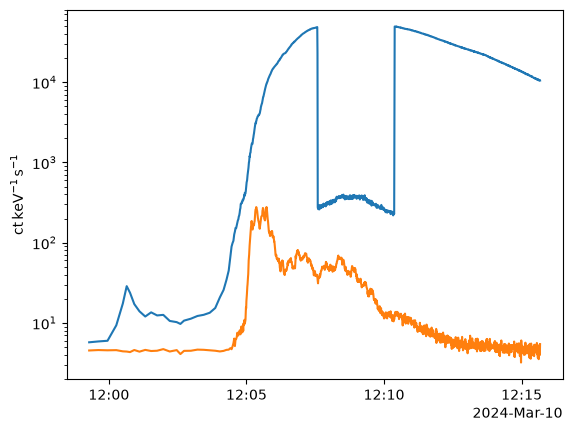

In [24]:
# Plot the timeseries for [6-12] keV and [20-50] keV

cpd_sci.plot_timeseries(energy_indices=[[2,8],[14,23]])


Set time and energy ranges which will be considered for the science and the background file



In [5]:

import pandas as pd
from datetime import timedelta

# st = pd.to_datetime("2024-03-10T12:08:58") - timedelta(seconds=215.91)
# et = pd.to_datetime("2024-03-10T12:09:10") - timedelta(seconds=215.91)

st = pd.to_datetime("2024-03-10T12:08:53") - timedelta(seconds=215.91)
et = st + timedelta(seconds=24)

# st = pd.to_datetime("2024-03-10T12:08:58") - timedelta(seconds=215.91)
# et = st  + timedelta(seconds=12)

print(st)
print(et)

2024-03-10 12:05:17.090000
2024-03-10 12:05:41.090000


In [6]:
time_range_sci = [st, et]
time_range_bkg = [
    "2024-03-08T19:30:00",
    "2024-03-08T20:40:00",
]  # Set this range larger than the actual observation time
energy_range = [4, 12] * u.keV
# energy_range = [4, 25] * u.keV

Create the meta pixel, A, B, C, D for the science and the background data



In [7]:
meta_pixels_sci = create_meta_pixels(
    cpd_sci, time_range=time_range_sci, energy_range=energy_range, flare_location=[0, 0] * u.arcsec, no_shadowing=True
)

meta_pixels_bkg = create_meta_pixels(
    cpd_bkg, time_range=time_range_bkg, energy_range=energy_range, flare_location=[0, 0] * u.arcsec, no_shadowing=True
)

/home/aip/anaconda3/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/aip/anaconda3/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


Perform background subtraction



In [8]:
meta_pixels_sci

{'abcd_rate_kev': <Quantity [[ 57.12146694,  50.64245146,  53.4156241 ,  60.02698693],
            [ 19.55057915,  30.35195155,  43.32439726,  36.82466955],
            [ 41.79531699,  14.81509248,  38.3900616 ,  76.96136307],
            [ 62.56648399,  36.35559857,  24.92281387,  53.45870205],
            [ 40.99421946,  35.78498163,  37.53089035,  42.19496621],
            [ 35.71501579,  31.42029643,  31.33236492,  34.73961694],
            [ 48.50377969,  47.52846791,  45.77194754,  46.35667989],
            [ 25.06433392,  28.3030505 ,  59.1133994 ,  55.53225445],
            [102.05935586, 104.40017928, 103.22815345,  63.40020367],
            [ 12.40435211,   1.05464117,   1.23703871,  12.26808182],
            [ 17.35341482,  19.75890784,  19.14263367,  19.46101582],
            [ 17.84831569,  18.62142828,  20.40110957,  20.48630827],
            [  4.83973468,   5.18521337,   5.89814639,   5.90225641],
            [ 62.28111944,  65.11383966,  28.83189256,  23.79666062],
   

In [9]:
meta_pixels_bkg_subtracted = {
    **meta_pixels_sci,
    "abcd_rate_kev_cm": meta_pixels_sci["abcd_rate_kev_cm"] - meta_pixels_bkg["abcd_rate_kev_cm"],
    "abcd_rate_error_kev_cm": np.sqrt(
        meta_pixels_sci["abcd_rate_error_kev_cm"] ** 2 + meta_pixels_bkg["abcd_rate_error_kev_cm"] ** 2
    )
}

Create visibilities from the meta pixels



In [10]:
meta_pixels_bkg_subtracted

# np.shape(meta_pixels_bkg_subtracted['abcd_rate_kev'])

{'abcd_rate_kev': <Quantity [[ 57.12146694,  50.64245146,  53.4156241 ,  60.02698693],
            [ 19.55057915,  30.35195155,  43.32439726,  36.82466955],
            [ 41.79531699,  14.81509248,  38.3900616 ,  76.96136307],
            [ 62.56648399,  36.35559857,  24.92281387,  53.45870205],
            [ 40.99421946,  35.78498163,  37.53089035,  42.19496621],
            [ 35.71501579,  31.42029643,  31.33236492,  34.73961694],
            [ 48.50377969,  47.52846791,  45.77194754,  46.35667989],
            [ 25.06433392,  28.3030505 ,  59.1133994 ,  55.53225445],
            [102.05935586, 104.40017928, 103.22815345,  63.40020367],
            [ 12.40435211,   1.05464117,   1.23703871,  12.26808182],
            [ 17.35341482,  19.75890784,  19.14263367,  19.46101582],
            [ 17.84831569,  18.62142828,  20.40110957,  20.48630827],
            [  4.83973468,   5.18521337,   5.89814639,   5.90225641],
            [ 62.28111944,  65.11383966,  28.83189256,  23.79666062],
   

In [11]:
tot = (meta_pixels_bkg_subtracted['abcd_rate_kev_cm'] * meta_pixels_bkg_subtracted['areas']) * np.diff(meta_pixels_bkg_subtracted['energy_range']) * meta_pixels_bkg_subtracted['time_range'].seconds  

counts = np.sum(tot)

counts

<Quantity 933102.19412694 ct>

In [12]:
vis = create_visibility(meta_pixels_bkg_subtracted)

Obtain the necessary ephemeris data create HPC 0,0 coordinate



In [13]:
vis_tr = TimeRange(vis.meta["time_range"])
roll, solo_xyz, pointing = get_hpc_info(vis_tr.start, vis_tr.end)
solo = HeliographicStonyhurst(*solo_xyz, obstime=vis_tr.center, representation_type="cartesian")
center_hpc = SkyCoord(0 * u.deg, 0 * u.deg, frame=Helioprojective(obstime=vis_tr.center, observer=solo))

2026-05-29 11:28:45 - sunpy - WARNING: SunpyDeprecationWarning: pattern has been replaced with the format keyword. This comes with a new syntax and there is a migration guide available at https://docs.sunpy.org/en/latest/topic_guide/scraper_migration.html.
2026-05-29 11:28:45 - sunpy - WARNING: SunpyDeprecationWarning: pattern has been replaced with the format keyword. This comes with a new syntax and there is a migration guide available at https://docs.sunpy.org/en/latest/topic_guide/scraper_migration.html.


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

2026-05-29T11:28:49Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec
2026-05-29 11:28:49 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec


Calibrate the visibilities

If not given will default to sun center flare location



In [14]:
cal_vis = calibrate_visibility(vis, flare_location=center_hpc)

2026-05-29T11:28:54Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec
2026-05-29 11:28:54 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec


2026-05-29 11:28:54 - sunpy - WARNING: SunpyDeprecationWarning: pattern has been replaced with the format keyword. This comes with a new syntax and there is a migration guide available at https://docs.sunpy.org/en/latest/topic_guide/scraper_migration.html.
2026-05-29 11:28:54 - sunpy - WARNING: SunpyDeprecationWarning: pattern has been replaced with the format keyword. This comes with a new syntax and there is a migration guide available at https://docs.sunpy.org/en/latest/topic_guide/scraper_migration.html.


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

2026-05-29T11:28:58Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec
2026-05-29 11:28:58 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec


Selected detectors 10 to 7



In [15]:
# order by sub-collimator e.g. 10a, 10b, 10c, 9a, 9b, 9c ....
isc_10_7 = [3, 20, 22, 16, 14, 32, 21, 26, 4, 24, 8, 28]
idx = np.argwhere(np.isin(cal_vis.meta["isc"], isc_10_7)).ravel()

Slice the visibilities to detectors 10 - 7



In [16]:
vis10_7 = cal_vis[idx]

Set up image parameters



In [17]:
imsize = [512, 512] * u.pixel  # number of pixels of the map to reconstruct
pixel = [10, 10] * u.arcsec / u.pixel  # pixel size in arcsec

Make a full disk back projection (inverse transform) map



In [18]:
bp_image = vis_to_image(vis10_7, imsize, pixel_size=pixel)

Obtain the necessary ephemeris data



In [19]:
vis_tr = TimeRange(vis.meta["time_range"])
roll, solo_xyz, pointing = get_hpc_info(vis_tr.start, vis_tr.end)
solo = HeliographicStonyhurst(*solo_xyz, obstime=vis_tr.center, representation_type="cartesian")
coord_stix = center_hpc.transform_to(STIXImaging(obstime=vis_tr.start, obstime_end=vis_tr.end, observer=solo))
header = make_fitswcs_header(
    bp_image, coord_stix, telescope="STIX", observatory="Solar Orbiter", scale=[10, 10] * u.arcsec / u.pix
)
fd_bp_map = Map((bp_image, header))

2026-05-29T11:29:04Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec
2026-05-29 11:29:04 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec


2026-05-29T11:29:04Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec
2026-05-29 11:29:04 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec


Convert the coordinates and make a map in Helioprojective and rotate so "North" is "up"
Center of STIX pointing in HPC



In [20]:
header_hp = make_fitswcs_header(
    bp_image, center_hpc, scale=[10, 10] * u.arcsec / u.pix, rotation_angle=90 * u.deg + roll
)
hp_map = Map((bp_image, header_hp))
hp_map_rotated = hp_map.rotate()

Plot the both maps



2026-05-29 11:29:08 - sunpy - WARNING: SunpyDeprecationWarning: pattern has been replaced with the format keyword. This comes with a new syntax and there is a migration guide available at https://docs.sunpy.org/en/latest/topic_guide/scraper_migration.html.
2026-05-29 11:29:08 - sunpy - WARNING: SunpyDeprecationWarning: pattern has been replaced with the format keyword. This comes with a new syntax and there is a migration guide available at https://docs.sunpy.org/en/latest/topic_guide/scraper_migration.html.


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

2026-05-29T11:29:11Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec
2026-05-29 11:29:11 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec


<CoordinatesMap with 2 world coordinates:

  index aliases    type   unit    wrap   format_unit visible
  ----- ------- --------- ---- --------- ----------- -------
      0     lon longitude  deg 180.0 deg         deg     yes
      1     lat  latitude  deg      None         deg     yes

>

2026-05-29T11:29:12Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec
2026-05-29 11:29:12 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec
2026-05-29T11:29:12Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec
2026-05-29 11:29:12 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec
2026-05-29T11:29:12Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec
2026-05-29 11:29:12 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec
2026-05-29T11:29:12Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec
2026-05-29 11:29:12 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec
2026-05-29T11:29:12Z INFO stixpy.coordinates.transforms 141:

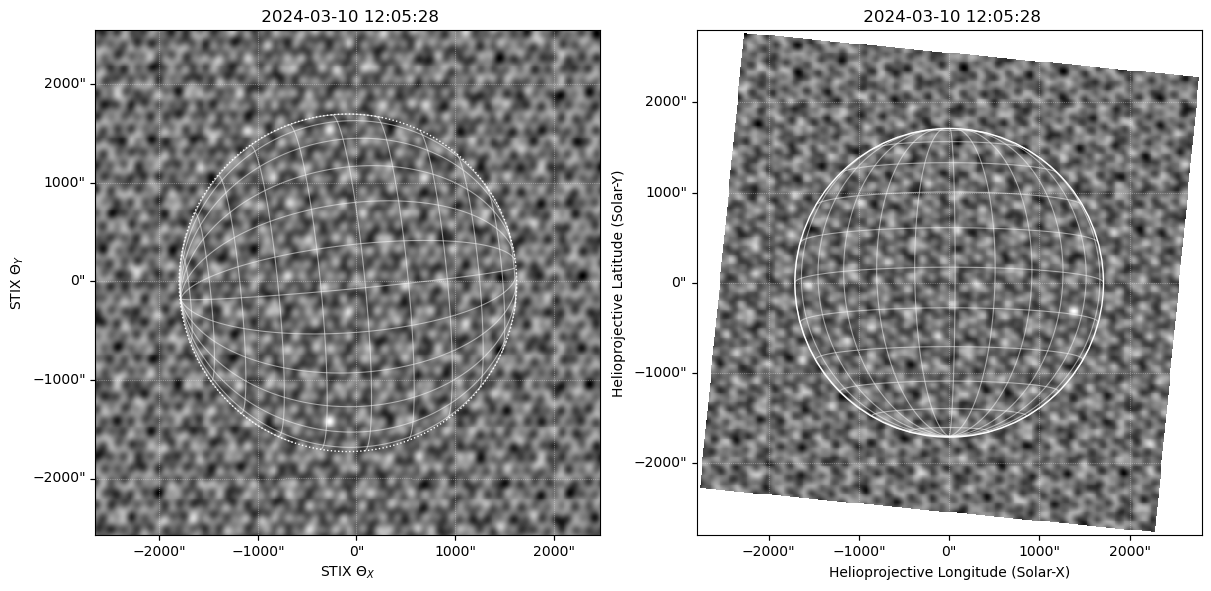

In [21]:
fig = plt.figure(layout="constrained", figsize=(12, 6))
ax = fig.subplot_mosaic(
    [["stix", "hpc"]], per_subplot_kw={"stix": {"projection": fd_bp_map}, "hpc": {"projection": hp_map_rotated}}
)
fd_bp_map.plot(axes=ax["stix"])
fd_bp_map.draw_limb()
fd_bp_map.draw_grid()

hp_map_rotated.plot(axes=ax["hpc"])
hp_map_rotated.draw_limb()
hp_map_rotated.draw_grid()

Estimate the flare location and plot on top of back projection map. Note the coordinates
are automatically converted from the STIXImaging to Helioprojective



In [22]:
max_pixel = np.argwhere(fd_bp_map.data == fd_bp_map.data.max()).ravel() * u.pixel
# because WCS axes and array are reversed
max_stix = fd_bp_map.pixel_to_world(max_pixel[1], max_pixel[0])

ax["stix"].plot_coord(max_stix, marker=".", markersize=50, fillstyle="none", color="r", markeredgewidth=2)
ax["hpc"].plot_coord(max_stix, marker=".", markersize=50, fillstyle="none", color="r", markeredgewidth=2)
fig.tight_layout()

2026-05-29T11:29:39Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec
2026-05-29 11:29:39 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec
2026-05-29T11:29:39Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec
2026-05-29 11:29:39 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec
2026-05-29T11:29:39Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec
2026-05-29 11:29:39 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec
2026-05-29T11:29:39Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec
2026-05-29 11:29:39 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec
2026-05-29T11:29:39Z INFO stixpy.coordinates.transforms 141:

Use estimated flare location to create more accurate visibilities



In [23]:
meta_pixels_sci = create_meta_pixels(
    cpd_sci, time_range=time_range_sci, energy_range=energy_range, flare_location=max_stix, no_shadowing=True
)

meta_pixels_bkg_subtracted = {
    **meta_pixels_sci,
    "abcd_rate_kev_cm": meta_pixels_sci["abcd_rate_kev_cm"] - meta_pixels_bkg["abcd_rate_kev_cm"],
    "abcd_rate_error_kev_cm": np.sqrt(
        meta_pixels_sci["abcd_rate_error_kev_cm"] ** 2 + meta_pixels_bkg["abcd_rate_error_kev_cm"] ** 2
    ),
}

vis = create_visibility(meta_pixels_bkg_subtracted)
cal_vis = calibrate_visibility(vis, flare_location=max_stix)

/home/aip/anaconda3/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
2026-05-29T11:29:44Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec
2026-05-29 11:29:44 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec


Selected detectors 10 to 3
order by sub-collimator e.g. 10a, 10b, 10c, 9a, 9b, 9c ....



In [24]:
isc_10_3 = [3, 20, 22, 16, 14, 32, 21, 26, 4, 24, 8, 28, 15, 27, 31, 6, 30, 2, 25, 5, 23, 7, 29, 1]
idx = np.argwhere(np.isin(cal_vis.meta["isc"], isc_10_3)).ravel()

Create an ``xrayvsion`` visibility object



In [25]:
cal_vis.meta["offset"] = max_stix
vis10_3 = cal_vis[idx]

Set up image parameters



In [26]:
imsize = [129, 129] * u.pixel  # number of pixels of the map to reconstruct
pixel = [2, 2] * u.arcsec / u.pixel  # pixel size in arcsec

Create a back projection image with natural weighting



In [27]:
bp_nat = vis_to_image(vis10_3, imsize, pixel_size=pixel)

Create a back projection image with uniform weighting



In [28]:
bp_uni = vis_to_image(vis10_3, imsize, pixel_size=pixel, scheme="uniform")

Create a `sunpy.map.Map` with back projection



In [29]:
bp_map = vis_to_map(vis10_3, imsize, pixel_size=pixel)

Crete a clean image using the clean algorithm `vis_clean`



In [30]:
niter = 200  # number of iterations
gain = 0.1  # gain used in each clean iteration
beam_width = 20.0 * u.arcsec
clean_map, model_map, resid_map = vis_clean(
    vis10_3, imsize, pixel_size=pixel, gain=gain, niter=niter, clean_beam_width=20 * u.arcsec
)

2026-05-29T11:29:58Z INFO xrayvision.clean 124: Iter: 0, strength: 434.56343504245785, location: (np.int64(64), np.int64(65))
2026-05-29 11:29:58 - xrayvision.clean - INFO: Iter: 0, strength: 434.56343504245785, location: (np.int64(64), np.int64(65))
2026-05-29T11:29:58Z INFO xrayvision.clean 124: Iter: 25, strength: 95.83329320568927, location: (np.int64(70), np.int64(74))
2026-05-29 11:29:58 - xrayvision.clean - INFO: Iter: 25, strength: 95.83329320568927, location: (np.int64(70), np.int64(74))
2026-05-29T11:29:58Z INFO xrayvision.clean 124: Iter: 50, strength: 39.54985012435528, location: (np.int64(44), np.int64(56))
2026-05-29 11:29:58 - xrayvision.clean - INFO: Iter: 50, strength: 39.54985012435528, location: (np.int64(44), np.int64(56))
2026-05-29T11:29:58Z INFO xrayvision.clean 124: Iter: 75, strength: 20.335115742174647, location: (np.int64(86), np.int64(74))
2026-05-29 11:29:58 - xrayvision.clean - INFO: Iter: 75, strength: 20.335115742174647, location: (np.int64(86), np.int64

Create a sunpy map for the clean image in Helioprojective



In [31]:
header = make_fitswcs_header(
    clean_map.data,
    max_stix.transform_to(Helioprojective(obstime=vis_tr.center, observer=solo)),
    telescope="STIX",
    observatory="Solar Orbiter",
    scale=pixel,
    rotation_angle=90 * u.deg + roll,
    
)

2026-05-29T11:30:06Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec
2026-05-29 11:30:06 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec


Crete a map using the MEM GE algorithm `mem`



In [32]:
snr_value, _ = resistant_mean((np.abs(vis10_3.visibilities) / vis10_3.amplitude_uncertainty).flatten(), 3)
percent_lambda = 2 / (snr_value**2 + 90)
mem_map = mem(vis10_3, shape=imsize, pixel_size=pixel, percent_lambda=percent_lambda)

2026-05-29T11:30:06Z INFO xrayvision.mem 159: Iter: 0, Chi2: 5139.5593731000245
2026-05-29 11:30:06 - xrayvision.mem - INFO: Iter: 0, Chi2: 5139.5593731000245
2026-05-29T11:30:06Z INFO xrayvision.mem 159: Iter: 25, Chi2: 117.62007299556112
2026-05-29 11:30:06 - xrayvision.mem - INFO: Iter: 25, Chi2: 117.62007299556112
2026-05-29T11:30:06Z INFO xrayvision.mem 159: Iter: 50, Chi2: 42.438253822022105
2026-05-29 11:30:06 - xrayvision.mem - INFO: Iter: 50, Chi2: 42.438253822022105
2026-05-29T11:30:06Z INFO xrayvision.mem 159: Iter: 75, Chi2: 28.286636627724526
2026-05-29 11:30:06 - xrayvision.mem - INFO: Iter: 75, Chi2: 28.286636627724526
2026-05-29T11:30:06Z INFO xrayvision.mem 159: Iter: 100, Chi2: 22.25127914771733
2026-05-29 11:30:06 - xrayvision.mem - INFO: Iter: 100, Chi2: 22.25127914771733
2026-05-29T11:30:07Z INFO xrayvision.mem 510: Iter: 0, Obj function: (3304.186434614807+0j)
2026-05-29 11:30:07 - xrayvision.mem - INFO: Iter: 0, Obj function: (3304.186434614807+0j)
2026-05-29T11:

Crete a map using the EM algorithm `EM`



In [34]:
em_map = em(
    meta_pixels_bkg_subtracted["abcd_rate_kev_cm"],
    cal_vis,
    shape=imsize,
    pixel_size=pixel,
    flare_location=max_stix,
    idx=idx,
)


clean_map = Map((clean_map.data, header)).rotate()
bp_map = Map((bp_nat, header)).rotate()
mem_map = Map((mem_map.data, header)).rotate()
em_map = Map((em_map, header)).rotate()

vmax = max([clean_map.data.max(), mem_map.data.max(), em_map.data.max()])

# mem_map.save('4-25_mem.fits',overwrite=True)
# em_map.save('4-25_em.fits',overwrite=True)

# mem_map.save('../aia/stix_aia_25-65_mem.fits',overwrite=True)
# em_map.save('../aia/stix_aia_25-65_em.fits',overwrite=True)


mem_map.save('../aia/stix_aia_4-12_mem_1700.fits',overwrite=True)
em_map.save('../aia/stix_aia_4-12_em_1700.fits',overwrite=True)

# mem_map.save('../aia/stix_aia_25-65_mem_1700.fits',overwrite=True)
# em_map.save('../aia/stix_aia_25-65_em_1700.fits',overwrite=True)


# mem_map.save('../aia/stix_aia_4-25_mem_1700.fits',overwrite=True)
# em_map.save('../aia/stix_aia_4-25_em_1700.fits',overwrite=True)

# mem_map.save('../aia/stix_aia_4-25_mem_171.fits',overwrite=True)
# em_map.save('../aia/stix_aia_4-25_em_171.fits',overwrite=True)


# mem_map.save('../aia/stix_aia_25-65_mem_171.fits',overwrite=True)
# em_map.save('../aia/stix_aia_25-65_em_171.fits',overwrite=True)

2026-05-29T11:30:45Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec
2026-05-29 11:30:45 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-15.94779873  86.49834591]] arcsec


2026-05-29T11:30:45Z INFO stixpy.imaging.em 180: Iteration: 25, StdDeV: 30.74661873123772, C-stat: 12.444387832948808
2026-05-29 11:30:45 - stixpy.imaging.em - INFO: Iteration: 25, StdDeV: 30.74661873123772, C-stat: 12.444387832948808
2026-05-29T11:30:46Z INFO stixpy.imaging.em 180: Iteration: 50, StdDeV: 6.9059404085649865, C-stat: 6.198110951182575
2026-05-29 11:30:46 - stixpy.imaging.em - INFO: Iteration: 50, StdDeV: 6.9059404085649865, C-stat: 6.198110951182575
2026-05-29T11:30:46Z INFO stixpy.imaging.em 180: Iteration: 75, StdDeV: 1.1842184887917127, C-stat: 4.409893712888895
2026-05-29 11:30:46 - stixpy.imaging.em - INFO: Iteration: 75, StdDeV: 1.1842184887917127, C-stat: 4.409893712888895
2026-05-29T11:30:46Z INFO stixpy.imaging.em 180: Iteration: 100, StdDeV: 0.2560589675187269, C-stat: 3.950498154311495
2026-05-29 11:30:46 - stixpy.imaging.em - INFO: Iteration: 100, StdDeV: 0.2560589675187269, C-stat: 3.950498154311495
2026-05-29T11:30:46Z INFO stixpy.imaging.em 180: Iteration

Finally compare the images from each algorithm



2026-05-29 11:30:48 - sunpy - INFO: Using image-based autoalignment
2026-05-29 11:30:48 - sunpy - INFO: Using image-based autoalignment


INFO: Using image-based autoalignment [sunpy.map.mapbase]
INFO: Using image-based autoalignment [sunpy.map.mapbase]


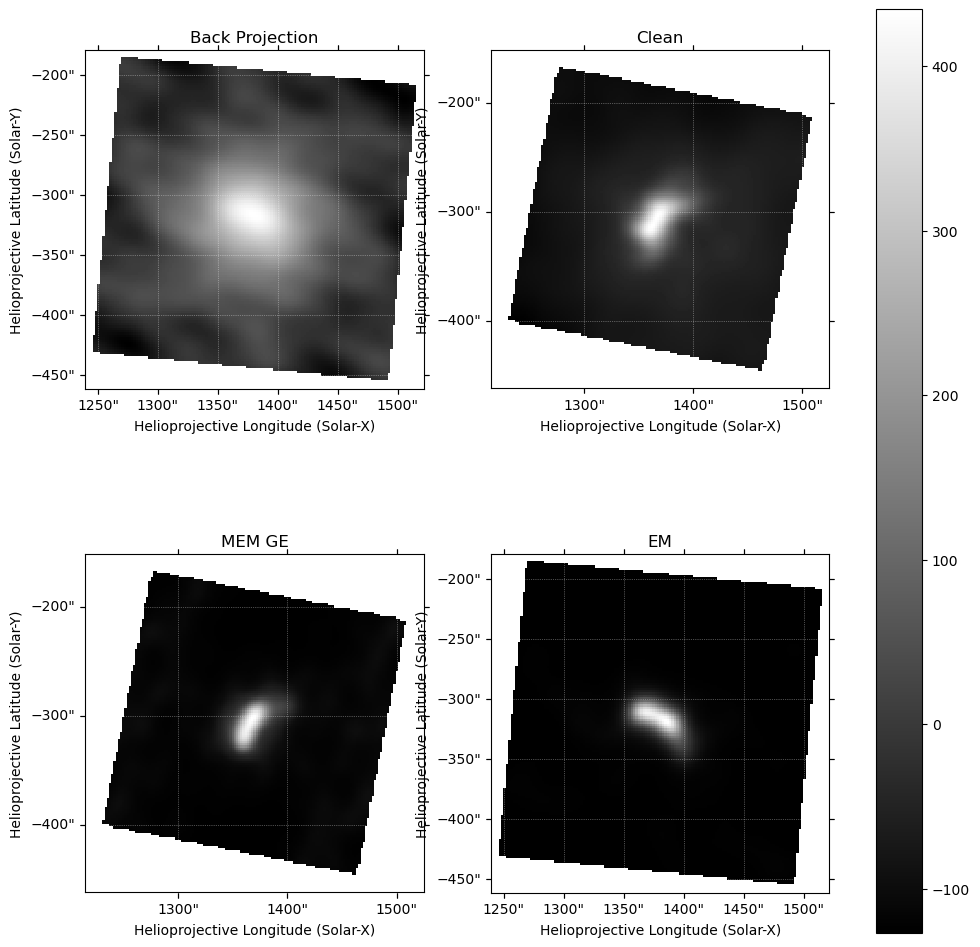

In [35]:
fig = plt.figure(figsize=(12, 12))
ax = fig.subplot_mosaic(
    [
        ["bp", "clean"],
        ["mem", "em"],
    ],
    subplot_kw={"projection": clean_map},
)
a = bp_map.plot(axes=ax["bp"])
ax["bp"].set_title("Back Projection")
b = clean_map.plot(axes=ax["clean"])
ax["clean"].set_title("Clean")
c = mem_map.plot(axes=ax["mem"])
ax["mem"].set_title("MEM GE")
d = em_map.plot(axes=ax["em"])
ax["em"].set_title("EM")
fig.colorbar(a, ax=ax.values())
plt.show()

/home/aip/anaconda3/lib/python3.13/site-packages/astropy/visualization/wcsaxes/core.py:248: UserWarning: The following kwargs were not used by contour: 'label'
  cset = super().contour(*args, **kwargs)
/home/aip/anaconda3/lib/python3.13/site-packages/astropy/visualization/wcsaxes/core.py:248: UserWarning: The following kwargs were not used by contour: 'label'
  cset = super().contour(*args, **kwargs)


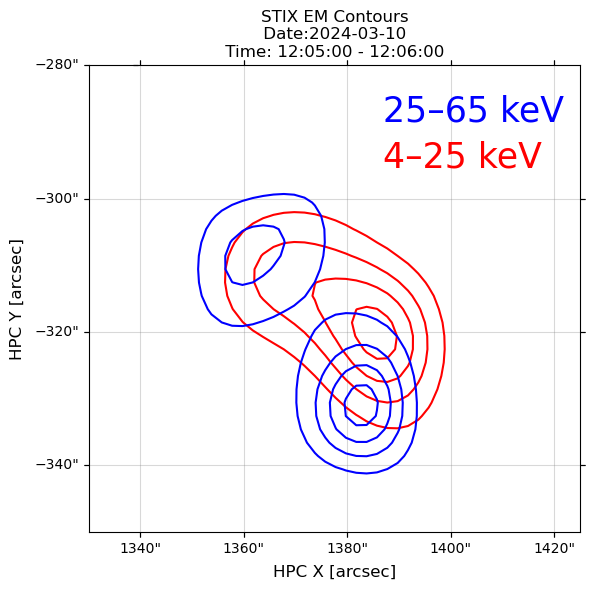

In [36]:
import matplotlib.pyplot as plt
import sunpy.map
import numpy as np

# Load maps
map_low = sunpy.map.Map("4-25_em.fits")
map_high = sunpy.map.Map("25-65_em.fits")

# Create WCS-aware figure
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection=map_low)

# Choose contour levels (as percentages of max)
levels_low = np.array([30,50, 70, 90]) * u.percent
levels_high = np.array([30,50, 70, 90]) * u.percent


# Plot contours
map_low.draw_contours(
    levels=levels_low,
    axes=ax,
    colors="red",
    linewidths=1.5,
    label='4-25 keV')

map_high.draw_contours(
    levels=levels_high,
    axes=ax,
    colors="blue",
    linewidths=1.5,
    label='25-65 keV')



# Draw solar limb
map_low.draw_limb(axes=ax, color="black", linewidth=1.5)

xlims_world = [1330, 1425]*u.arcsec
ylims_world = [-350, -280]*u.arcsec

world_coords = SkyCoord(Tx=xlims_world, Ty=ylims_world, frame=map_low.coordinate_frame)
pixel_coords_x, pixel_coords_y = map_low.wcs.world_to_pixel(world_coords)

ax.set_xlim(pixel_coords_x)
ax.set_ylim(pixel_coords_y)
# Labels & title
ax.set_title("STIX EM Contours\n Date:2024-03-10 \n Time: 12:05:00 - 12:06:00 ")

ax.text(0.6, 0.78, "4–25 keV", color='red', fontsize=25,transform=ax.transAxes)
ax.text(0.6, 0.88, "25–65 keV", color='blue', fontsize=25,transform=ax.transAxes)


"2024-03-10T12:05:00", "2024-03-10T12:06:00"

ax.grid(color="gray", alpha=0.3)

ax.set_xlabel("HPC X [arcsec]", fontsize=12)
ax.set_ylabel("HPC Y [arcsec]", fontsize=12)

plt.tight_layout()
plt.show()

fig.savefig('image.png',bbox_inches='tight')

In [37]:
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
from scipy import ndimage

def hpc_centroids_multi(map_obj, level=50*u.percent, min_pixels=10):
    data = np.asarray(map_obj.data, dtype=float)

    # Remove NaNs early
    finite_data = np.isfinite(data)
    data[~finite_data] = 0.0

    # Threshold
    if level.unit == u.percent:
        threshold = (level / 100.0) * np.nanmax(data)
    else:
        threshold = level

    if threshold <= 0:
        raise ValueError("Contour threshold is non-positive")

    mask = data >= threshold

    # Label connected regions
    labels, num = ndimage.label(mask)

    centroids = []

    # Pixel grid
    yy, xx = np.indices(data.shape)
    hpc = map_obj.pixel_to_world(xx * u.pixel, yy * u.pixel)

    # Finite HPC coordinates only
    finite_hpc = np.isfinite(hpc.Tx.value) & np.isfinite(hpc.Ty.value)

    for label in range(1, num + 1):
        region = (labels == label) & finite_hpc

        if np.sum(region) < min_pixels:
            continue

        weights = data[region]

        x_vals = hpc.Tx.value[region]
        y_vals = hpc.Ty.value[region]

        # Guard against zero-weight regions
        if np.sum(weights) == 0:
            continue

        x_c = np.average(x_vals, weights=weights)
        y_c = np.average(y_vals, weights=weights)

        centroids.append(
            SkyCoord(
                x_c * u.arcsec,
                y_c * u.arcsec,
                frame=map_obj.coordinate_frame
            )
        )

    return centroids

In [29]:
cen =  hpc_centroids_multi(map_high, level=30*u.percent, min_pixels=100)

In [32]:
cen

[<SkyCoord (Helioprojective: obstime=2024-03-10T12:05:30.095, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2024-03-10T12:05:30.095, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, m)
     (-17.19355753, -5.76325796, 8.38577431e+10)>): (Tx, Ty) in arcsec
     (1470.5113674, -527.6417159)>,
 <SkyCoord (Helioprojective: obstime=2024-03-10T12:05:30.095, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2024-03-10T12:05:30.095, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, m)
     (-17.19355753, -5.76325796, 8.38577431e+10)>): (Tx, Ty) in arcsec
     (1257.78158538, -490.85303188)>,
 <SkyCoord (Helioprojective: obstime=2024-03-10T12:05:30.095, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2024-03-10T12:05:30.095, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, m)
     (-17.19355753, -5.76325796, 8.38577431e+10)>): (Tx, Ty) in arcsec
     (1482.06777064, -431.47652483)>,
 <SkyCoord (Helioprojective: obstime

/home/jmitchell/anaconda3/lib/python3.12/site-packages/astropy/visualization/wcsaxes/core.py:257: UserWarning: The following kwargs were not used by contour: 'label'
  cset = super().contour(*args, **kwargs)
/home/jmitchell/anaconda3/lib/python3.12/site-packages/astropy/visualization/wcsaxes/core.py:257: UserWarning: The following kwargs were not used by contour: 'label'
  cset = super().contour(*args, **kwargs)


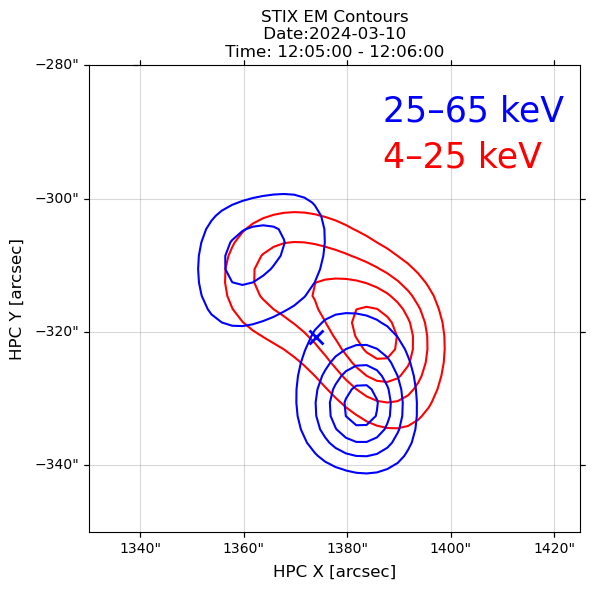

In [31]:
# Load maps
map_low = sunpy.map.Map("4-25_em.fits")
map_high = sunpy.map.Map("25-65_em.fits")

# Create WCS-aware figure
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection=map_low)

# Choose contour levels (as percentages of max)
levels_low = np.array([30,50, 70, 90]) * u.percent
levels_high = np.array([30,50, 70, 90]) * u.percent


# Plot contours
map_low.draw_contours(
    levels=levels_low,
    axes=ax,
    colors="red",
    linewidths=1.5,
    label='4-25 keV')

map_high.draw_contours(
    levels=levels_high,
    axes=ax,
    colors="blue",
    linewidths=1.5,
    label='25-65 keV')



# Draw solar limb
map_low.draw_limb(axes=ax, color="black", linewidth=1.5)

xlims_world = [1330, 1425]*u.arcsec
ylims_world = [-350, -280]*u.arcsec

world_coords = SkyCoord(Tx=xlims_world, Ty=ylims_world, frame=map_low.coordinate_frame)
pixel_coords_x, pixel_coords_y = map_low.wcs.world_to_pixel(world_coords)

ax.set_xlim(pixel_coords_x)
ax.set_ylim(pixel_coords_y)
# Labels & title
ax.set_title("STIX EM Contours\n Date:2024-03-10 \n Time: 12:05:00 - 12:06:00 ")

ax.text(0.6, 0.78, "4–25 keV", color='red', fontsize=25,transform=ax.transAxes)
ax.text(0.6, 0.88, "25–65 keV", color='blue', fontsize=25,transform=ax.transAxes)

# cen_coords = SkyCoord(Tx=cen[0].Tx, Ty=cen[0].Ty, frame=map_high.coordinate_frame)
# cen_coords_x, cen_coords_y = map_high.wcs.world_to_pixel(cen_coords)

for c in cen:
    ax.plot_coord(c, marker='x', color='blue', markersize=10, mew=2)

"2024-03-10T12:05:00", "2024-03-10T12:06:00"

ax.grid(color="gray", alpha=0.3)

ax.set_xlabel("HPC X [arcsec]", fontsize=12)
ax.set_ylabel("HPC Y [arcsec]", fontsize=12)

plt.tight_layout()
plt.show()

fig.savefig('image.png',bbox_inches='tight')

In [33]:
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from scipy import ndimage

def hpc_centroids_watershed(map_obj, level=30*u.percent, min_pixels=10):
    data = np.nan_to_num(map_obj.data, nan=0.0)

    if level.unit == u.percent:
        threshold = (level / 100) * np.nanmax(data)
    else:
        threshold = level

    mask = data >= threshold

    # Distance map
    distance = ndimage.distance_transform_edt(mask)

    # Find peaks (one per source)
    peaks = peak_local_max(distance, labels=mask, min_distance=5)
    markers = np.zeros_like(data, dtype=int)
    for i, (y, x) in enumerate(peaks, start=1):
        markers[y, x] = i

    labels = watershed(-distance, markers, mask=mask)

    # Compute centroids per region (same as before)
    centroids = []
    yy, xx = np.indices(data.shape)
    hpc = map_obj.pixel_to_world(xx*u.pixel, yy*u.pixel)
    finite = np.isfinite(hpc.Tx.value) & np.isfinite(hpc.Ty.value)

    for label in np.unique(labels):
        if label == 0:
            continue
        region = (labels == label) & finite
        if np.sum(region) < min_pixels:
            continue

        weights = data[region]
        x_c = np.average(hpc.Tx.value[region], weights=weights)
        y_c = np.average(hpc.Ty.value[region], weights=weights)

        centroids.append(
            SkyCoord(x_c*u.arcsec, y_c*u.arcsec,
                     frame=map_obj.coordinate_frame)
        )

    return centroids

In [54]:
cen =  hpc_centroids_watershed(map_high, level=45*u.percent, min_pixels=100)

In [55]:
cen

[<SkyCoord (Helioprojective: obstime=2024-03-10T12:05:30.095, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2024-03-10T12:05:30.095, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, m)
     (-17.19355753, -5.76325796, 8.38577431e+10)>): (Tx, Ty) in arcsec
     (1354.50703217, -312.86665721)>,
 <SkyCoord (Helioprojective: obstime=2024-03-10T12:05:30.095, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2024-03-10T12:05:30.095, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, m)
     (-17.19355753, -5.76325796, 8.38577431e+10)>): (Tx, Ty) in arcsec
     (1383.45052501, -324.31809943)>,
 <SkyCoord (Helioprojective: obstime=2024-03-10T12:05:30.095, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2024-03-10T12:05:30.095, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, m)
     (-17.19355753, -5.76325796, 8.38577431e+10)>): (Tx, Ty) in arcsec
     (1288.19271616, -291.84308579)>,
 <SkyCoord (Helioprojective: obsti

/home/jmitchell/anaconda3/lib/python3.12/site-packages/astropy/visualization/wcsaxes/core.py:257: UserWarning: The following kwargs were not used by contour: 'label'
  cset = super().contour(*args, **kwargs)
/home/jmitchell/anaconda3/lib/python3.12/site-packages/astropy/visualization/wcsaxes/core.py:257: UserWarning: The following kwargs were not used by contour: 'label'
  cset = super().contour(*args, **kwargs)


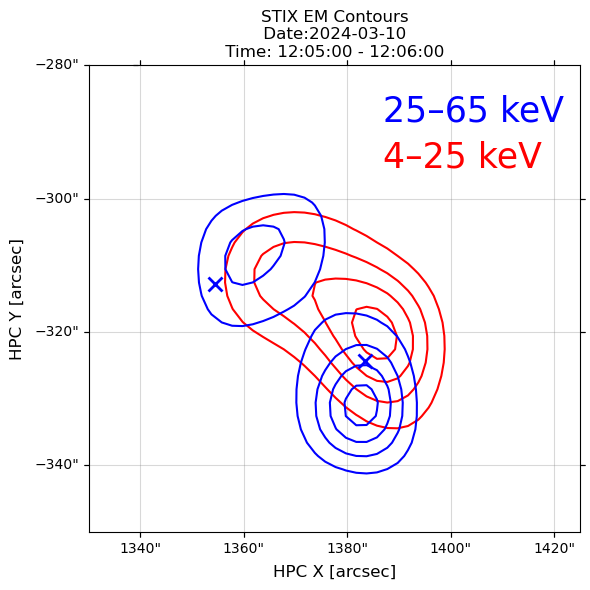

In [56]:
# Load maps
map_low = sunpy.map.Map("4-25_em.fits")
map_high = sunpy.map.Map("25-65_em.fits")

# Create WCS-aware figure
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection=map_low)

# Choose contour levels (as percentages of max)
levels_low = np.array([30,50, 70, 90]) * u.percent
levels_high = np.array([30,50, 70, 90]) * u.percent


# Plot contours
map_low.draw_contours(
    levels=levels_low,
    axes=ax,
    colors="red",
    linewidths=1.5,
    label='4-25 keV')

map_high.draw_contours(
    levels=levels_high,
    axes=ax,
    colors="blue",
    linewidths=1.5,
    label='25-65 keV')


# Draw solar limb
map_low.draw_limb(axes=ax, color="black", linewidth=1.5)

xlims_world = [1330, 1425]*u.arcsec
ylims_world = [-350, -280]*u.arcsec

world_coords = SkyCoord(Tx=xlims_world, Ty=ylims_world, frame=map_low.coordinate_frame)
pixel_coords_x, pixel_coords_y = map_low.wcs.world_to_pixel(world_coords)

ax.set_xlim(pixel_coords_x)
ax.set_ylim(pixel_coords_y)
# Labels & title
ax.set_title("STIX EM Contours\n Date:2024-03-10 \n Time: 12:05:00 - 12:06:00 ")

ax.text(0.6, 0.78, "4–25 keV", color='red', fontsize=25,transform=ax.transAxes)
ax.text(0.6, 0.88, "25–65 keV", color='blue', fontsize=25,transform=ax.transAxes)

# cen_coords = SkyCoord(Tx=cen[0].Tx, Ty=cen[0].Ty, frame=map_high.coordinate_frame)
# cen_coords_x, cen_coords_y = map_high.wcs.world_to_pixel(cen_coords)

for c in cen:
    ax.plot_coord(c, marker='x', color='blue', markersize=10, mew=2)



ax.grid(color="gray", alpha=0.3)

ax.set_xlabel("HPC X [arcsec]", fontsize=12)
ax.set_ylabel("HPC Y [arcsec]", fontsize=12)

plt.tight_layout()
plt.show()

fig.savefig('image.png',bbox_inches='tight')

In [1]:
import astropy.units as u
from sunpy.net import Fido, attrs as a


from matplotlib import pyplot as plt

import sunpy.map
from sunpy.net import Fido, attrs as a

from astropy import units as u

import warnings
from astropy.coordinates import SkyCoord
warnings.filterwarnings("ignore")

In [2]:
res = Fido.search(a.Time('2024-03-10T12:08:00', '2024-03-10T12:13:00'),a.Wavelength(1700*u.angstrom),a.jsoc.Series('aia.lev1_uv_24s'),a.jsoc.Notify('jmitchell@aip.de') )
res

# import os

# try:
#     os.mkdir('../aia/')
# except:
#     pass

# downloaded_files = Fido.fetch(res,path='../aia/')

T_REC,TELESCOP,INSTRUME,WAVELNTH,CAR_ROT
str20,str7,str5,int64,int64
2024-03-10T12:07:47Z,SDO/AIA,AIA_3,1700,2281
2024-03-10T12:08:11Z,SDO/AIA,AIA_3,1700,2281
2024-03-10T12:08:35Z,SDO/AIA,AIA_3,1700,2281
2024-03-10T12:08:59Z,SDO/AIA,AIA_3,1700,2281
2024-03-10T12:09:23Z,SDO/AIA,AIA_3,1700,2281
2024-03-10T12:09:47Z,SDO/AIA,AIA_3,1700,2281
2024-03-10T12:10:11Z,SDO/AIA,AIA_3,1700,2281
2024-03-10T12:10:35Z,SDO/AIA,AIA_3,1700,2281
2024-03-10T12:10:59Z,SDO/AIA,AIA_3,1700,2281
